# Install & Imports

In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb
import warnings
warnings.filterwarnings('ignore')

#Load & Clean Catalog

In [ ]:
df_products = pd.read_csv("products_catalog.csv")
print(f"Products loaded: {df_products.shape}")

# ── Explode product_colors into one row per shade ──────────────────────────
rows = []
for _, row in df_products.iterrows():
    try:
        colors_list = ast.literal_eval(row["product_colors"])
    except (ValueError, SyntaxError):
        continue
    for c in colors_list:
        rows.append({
            "id":           row["id"],
            "brand":        row["brand"],
            "name":         row["name"],
            "price":        row["price"],
            "currency":     row["currency"],
            "product_link": row["product_link"],
            "description":  row["description"],
            "category":     row["category"],
            "product_type": row["product_type"],
            "tag_list":     row["tag_list"],
            "undertone":    row["undertone"],
            "hex":          c["hex_value"].lstrip("#"),
            "shade_name":   c["colour_name"],
        })

df = pd.DataFrame(rows).reset_index(drop=True)
print(f"Shades after exploding: {df.shape}")

# ── Normalise hex ──────────────────────────────────────────────────────────
df["hex"] = df["hex"].astype(str).str.strip().str.upper().str.lstrip("#")
valid_mask = df["hex"].str.fullmatch(r"[0-9A-F]{6}")
n_dropped = (~valid_mask).sum()
df = df[valid_mask].reset_index(drop=True)
print(f"Dropped {n_dropped} malformed hex rows → final shape: {df.shape}")

# ── Decompose hex → R, G, B ────────────────────────────────────────────────
df["r"] = df["hex"].apply(lambda h: int(h[0:2], 16))
df["g"] = df["hex"].apply(lambda h: int(h[2:4], 16))
df["b"] = df["hex"].apply(lambda h: int(h[4:6], 16))

# ── Derived features ───────────────────────────────────────────────────────
df["luminance"] = 0.299 * df["r"] + 0.587 * df["g"] + 0.114 * df["b"]
df["rb_diff"]   = df["r"] - df["b"]

print(f"\nShade-level dataset ready: {len(df)} rows")
print(df["product_type"].value_counts())
df.head(3)

Products loaded: (630, 15)
Shades after exploding: (4800, 13)
Dropped 54 malformed hex rows → final shape: (4746, 13)

Shade-level dataset ready: 4746 rows
product_type
lipstick      1646
foundation    1282
eyeliner       429
eyeshadow      395
lip_liner      299
blush          279
eyebrow        170
bronzer        143
mascara        103
Name: count, dtype: int64


,id,brand,name,price,currency,product_link,description,category,product_type,tag_list,undertone,hex,shade_name,r,g,b,luminance,rb_diff
0,1,colourpop,Lippie Pencil,5.0,CAD,https://colourpop.com/collections/lippie-pencil,Lippie Pencil A long-wearing and high-intensit...,pencil,lip_liner,"['cruelty free', 'Vegan']",warm,B28378,BFF Pencil,178,131,120,143.799,58
1,1,colourpop,Lippie Pencil,5.0,CAD,https://colourpop.com/collections/lippie-pencil,Lippie Pencil A long-wearing and high-intensit...,pencil,lip_liner,"['cruelty free', 'Vegan']",warm,A36B5E,951 Pencil,163,107,94,122.262,69
2,1,colourpop,Lippie Pencil,5.0,CAD,https://colourpop.com/collections/lippie-pencil,Lippie Pencil A long-wearing and high-intensit...,pencil,lip_liner,"['cruelty free', 'Vegan']",warm,966A60,Beeper Pencil,150,106,96,118.016,54


# 1. Product count by category

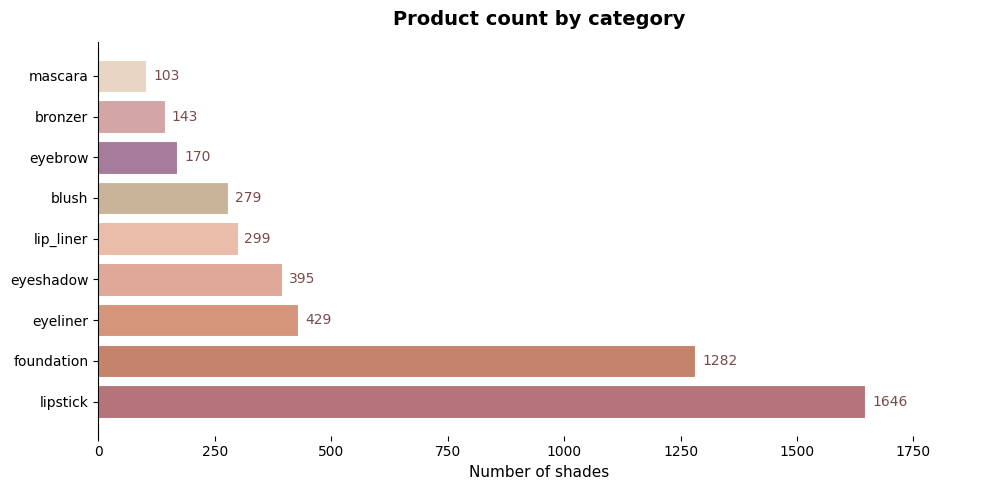


Figure 1 — Product count by category.


In [ ]:
counts = df['product_type'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#B5737A','#C4836A','#D4957A','#E0A898','#EABCAA',
              '#C9B49A','#A67B9B','#D4A5A5','#E8D5C4','#9B8EA0']
bars = ax.barh(counts.index, counts.values, color=colors_bar, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, color='#7A4A4A')
ax.set_xlabel("Number of shades", fontsize=11)
ax.set_title("Product count by category", fontsize=14, fontweight='bold', pad=12)
ax.spines[['top','right','bottom']].set_visible(False)
ax.set_xlim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig("fig1_product_counts.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 1 — Product count by category.")



#2. Undertone distribution by product type

In [ ]:
# ── Makeup-inspired color palette ──────────────────────────────────────────
WARM    = "#C4836A"   # terracotta
COOL    = "#A67B9B"   # mauve
NEUTRAL = "#C9B49A"   # nude beige

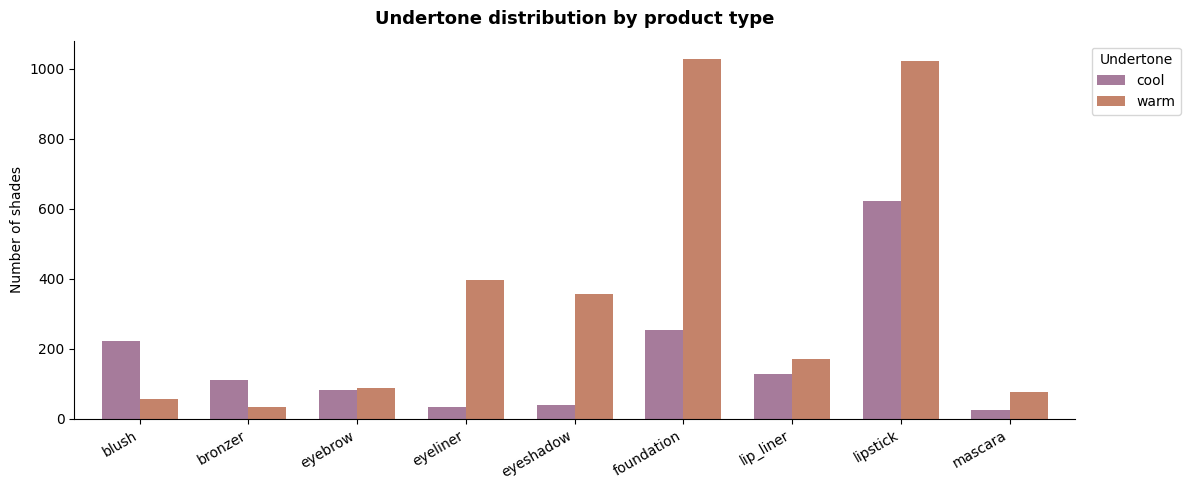


Figure 2 — Undertone distribution by product type.


In [ ]:
undertone_counts = df.groupby(["product_type", "undertone"]).size().unstack(fill_value=0)

colors = {"warm": WARM, "cool": COOL, "neutral": NEUTRAL}
ax = undertone_counts.plot(
    kind="bar",
    figsize=(12, 5),
    color=[colors[c] for c in undertone_counts.columns],
    edgecolor="none",
    width=0.7
)
ax.set_title("Undertone distribution by product type", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Number of shades")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Undertone", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig2_undertone_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 2 — Undertone distribution by product type.")

# 3. Foundation swatch grid


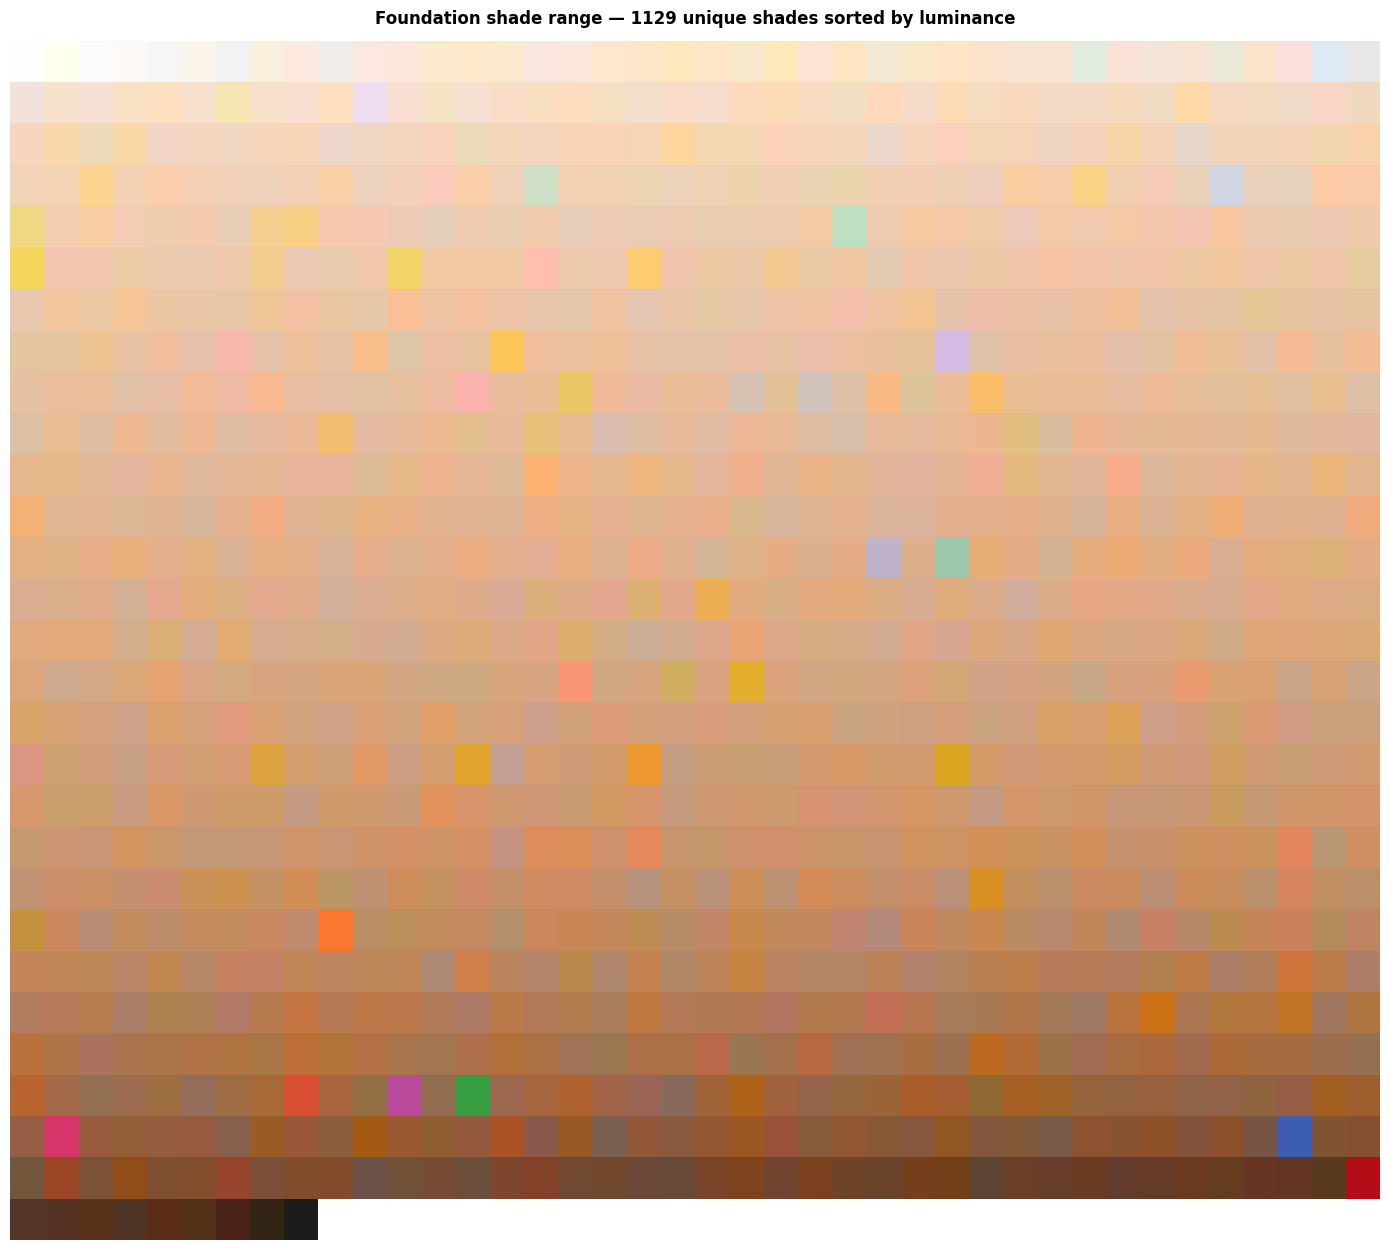


Figure 3 — Foundation Swatch Grid.


In [ ]:
foundation_shades = (
    df[df["product_type"] == "foundation"]
    .drop_duplicates(subset="hex")
    .sort_values("luminance", ascending=False)
    .reset_index(drop=True)
)

n = len(foundation_shades)
cols = 40
rows = (n // cols) + 1

fig, ax = plt.subplots(figsize=(14, rows * 0.4 + 1))
ax.set_xlim(0, cols)
ax.set_ylim(0, rows)
ax.axis("off")

for i, row in foundation_shades.iterrows():
    x = i % cols
    y = rows - 1 - (i // cols)
    ax.add_patch(plt.Rectangle((x, y), 1, 1,
                 color=f"#{row['hex']}", linewidth=0))

ax.set_title(f"Foundation shade range — {n} unique shades sorted by luminance",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig3_foundation_swatchgridn.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 3 — Foundation Swatch Grid.")

# 4. Hex rainbow across all shades:


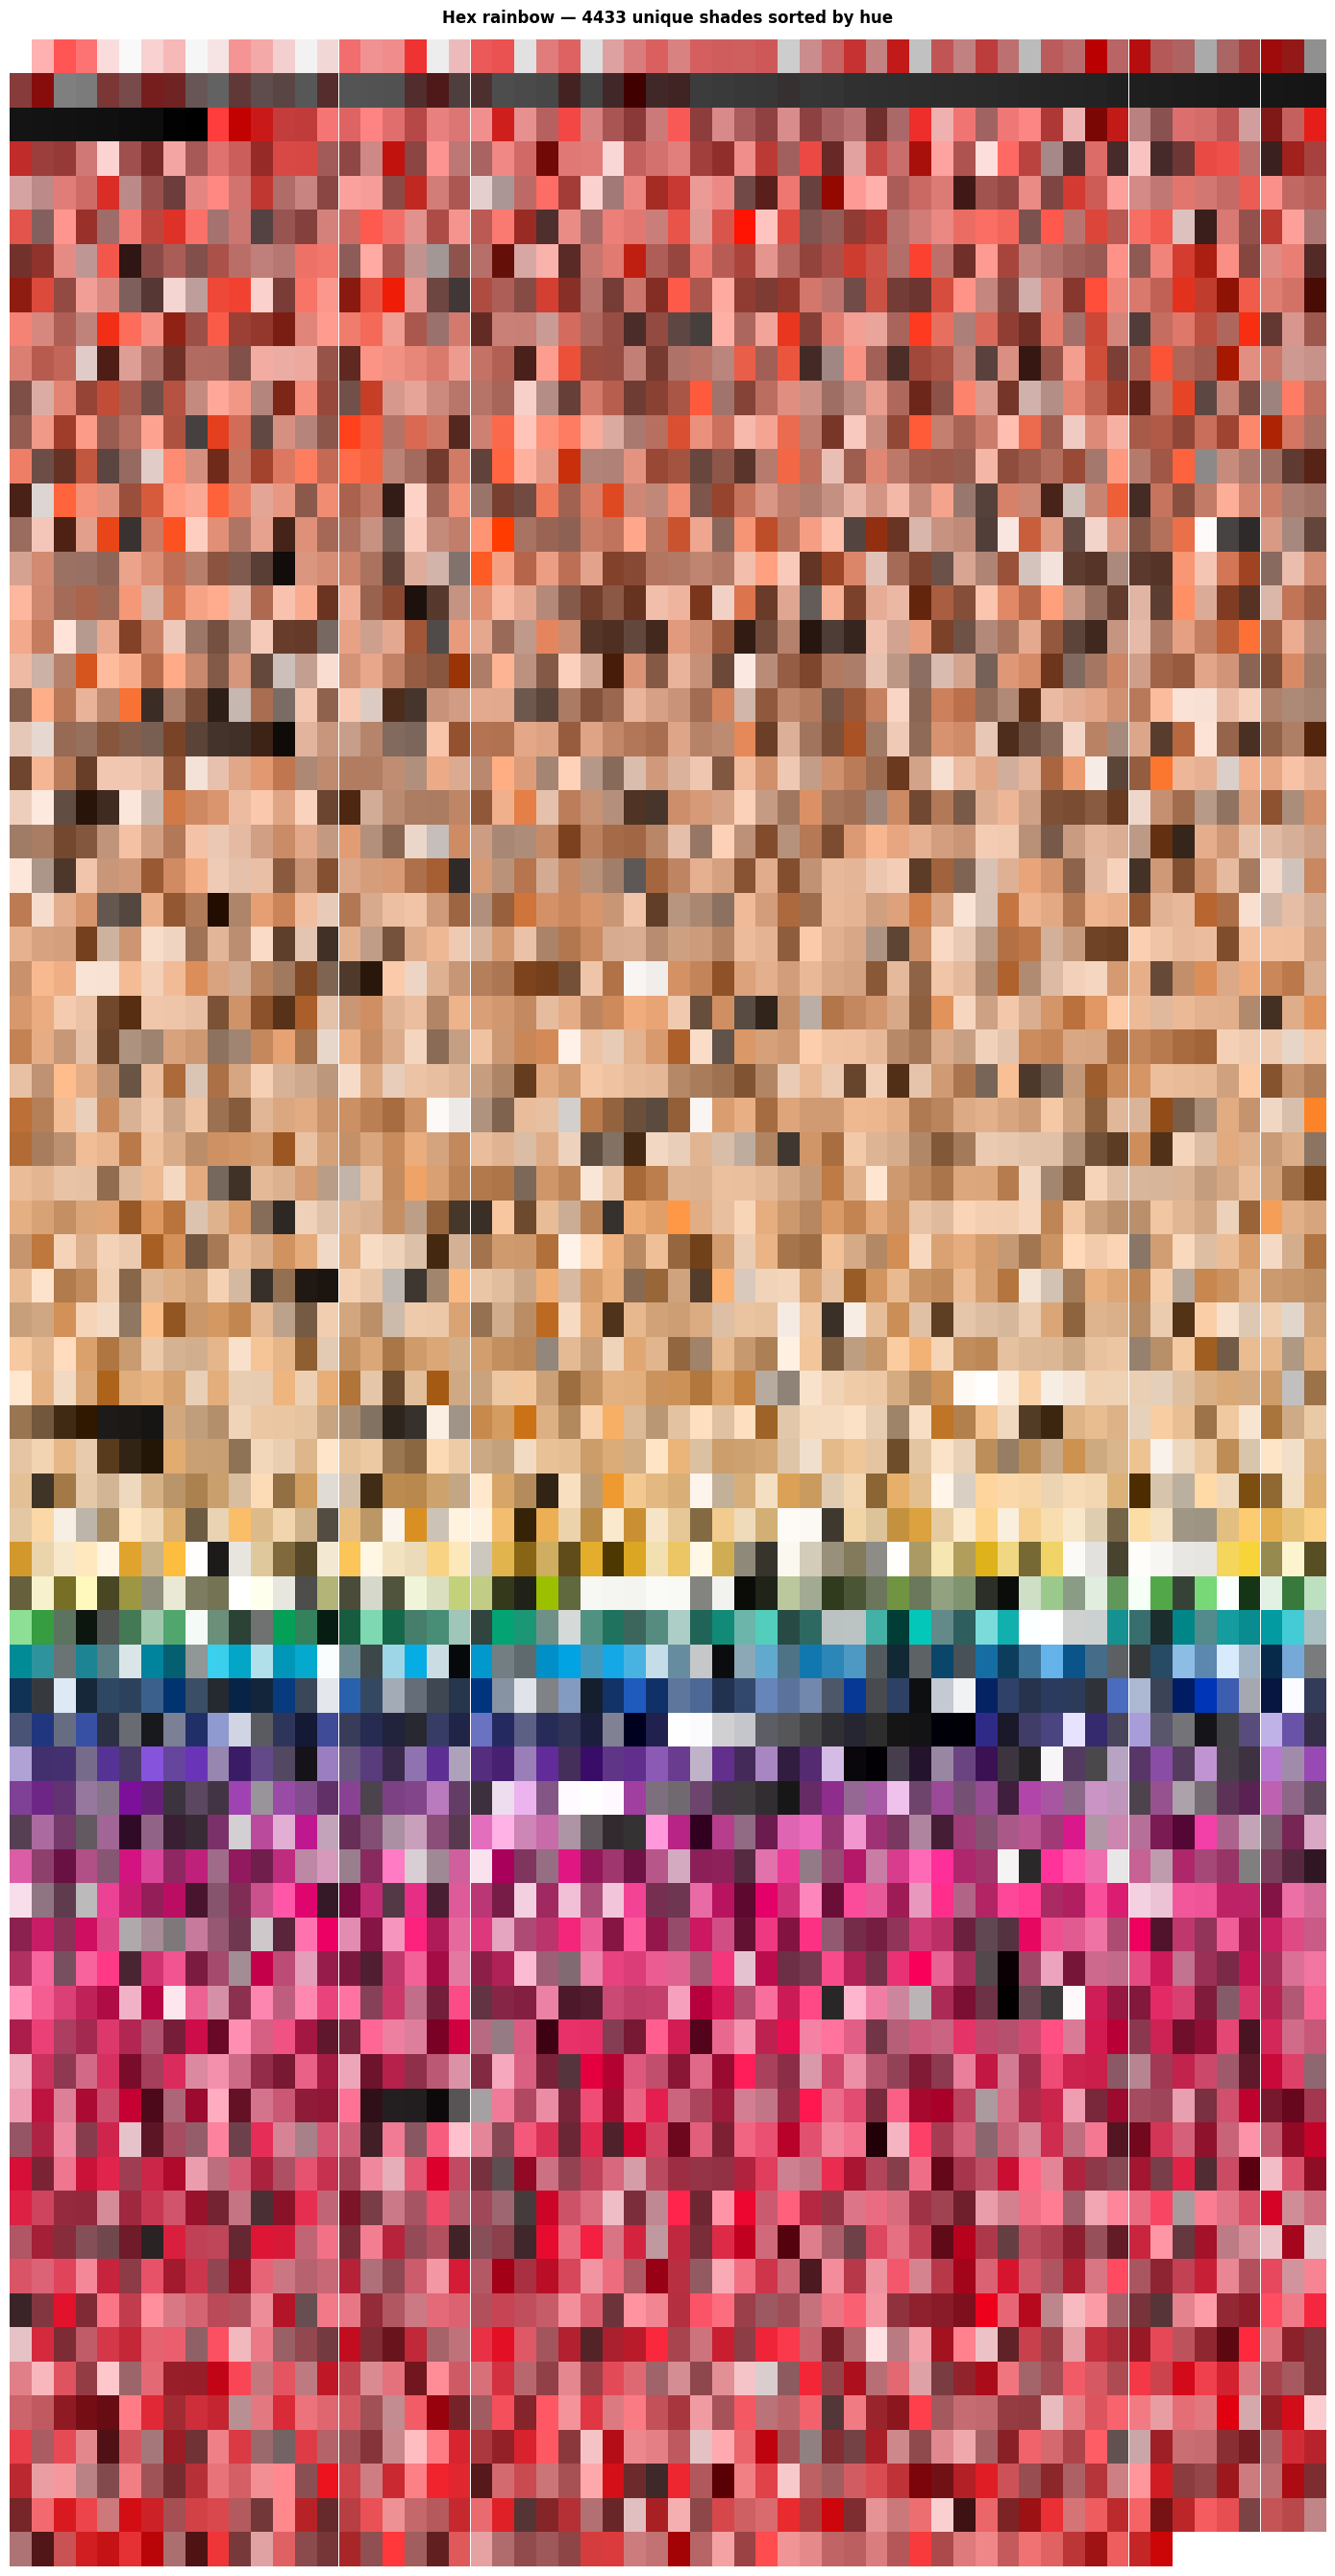

<Figure size 640x480 with 0 Axes>


Figure 4 — Hex rainbow across all shades.


In [ ]:
from matplotlib.colors import hsv_to_rgb
import colorsys

def hex_to_hsv(hex_str):
    r, g, b = int(hex_str[0:2],16)/255, int(hex_str[2:4],16)/255, int(hex_str[4:6],16)/255
    return colorsys.rgb_to_hsv(r, g, b)

all_shades = df.drop_duplicates(subset="hex").copy()
all_shades["hsv_h"] = all_shades["hex"].apply(lambda h: hex_to_hsv(h)[0])
all_shades["hsv_s"] = all_shades["hex"].apply(lambda h: hex_to_hsv(h)[1])
all_shades["hsv_v"] = all_shades["hex"].apply(lambda h: hex_to_hsv(h)[2])

# Sort by hue then value for a rainbow effect
all_shades = all_shades.sort_values(["hsv_h", "hsv_v"], ascending=[True, False]).reset_index(drop=True)

n = len(all_shades)
cols = 60
rows = (n // cols) + 1

fig, ax = plt.subplots(figsize=(14, rows * 0.35 + 1))
ax.set_xlim(0, cols)
ax.set_ylim(0, rows)
ax.axis("off")

for i, row in all_shades.iterrows():
    x = i % cols
    y = rows - 1 - (i // cols)
    ax.add_patch(plt.Rectangle((x, y), 1, 1,
                 color=f"#{row['hex']}", linewidth=0))

ax.set_title(f"Hex rainbow — {n} unique shades sorted by hue",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()
plt.savefig("fig4_hex_rainbow_shades.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 4 — Hex rainbow across all shades.")


# 5. Foundation coverage by Monk Skin Tone

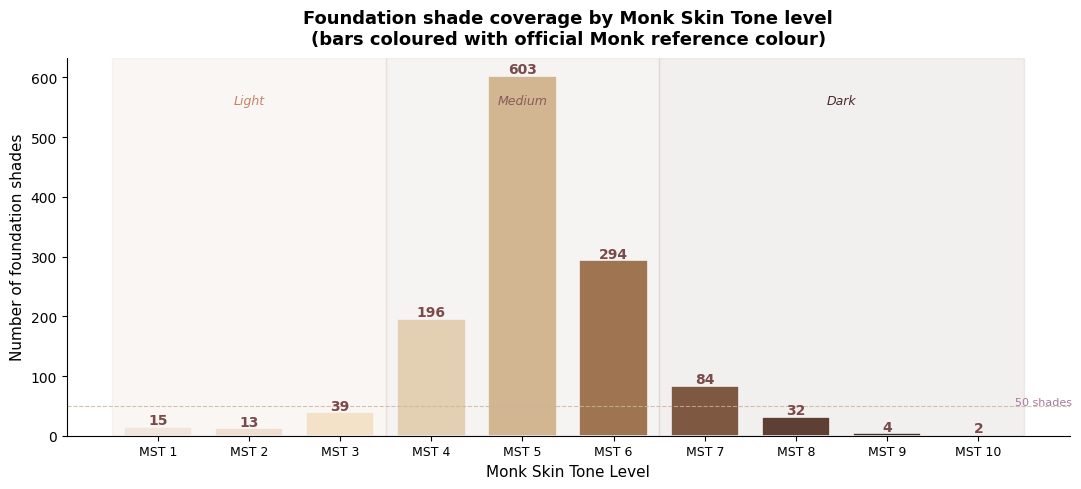


Figure 5 — Foundation coverage by Monk Skin Tone.


In [ ]:
MONK_HEX = ['f6ede4','f3e7db','f7ead0','eadaba','d7bd96',
            'a07850','825c43','604134','3a312a','292420']
MONK_RGB  = np.array([[int(h[i:i+2], 16) for i in (0, 2, 4)] for h in MONK_HEX])

def monk_distance(r, g, b):
    dists = np.sqrt(np.sum((MONK_RGB - np.array([r, g, b]))**2, axis=1))
    return int(np.argmin(dists)) + 1

foundations = df[df['product_type'] == 'foundation'].copy()
foundations['monk_level'] = foundations.apply(
    lambda row: monk_distance(row['r'], row['g'], row['b']), axis=1
)
monk_counts = foundations['monk_level'].value_counts().sort_index()
monk_counts = monk_counts.reindex(range(1, 11), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
monk_colors = ['#' + h for h in MONK_HEX]
bars = ax.bar(monk_counts.index, monk_counts.values,
              color=monk_colors, edgecolor='white', linewidth=1.2, width=0.75)

for bar, val in zip(bars, monk_counts.values):
    # light text for dark bars, dark text for light bars
    lum = 0.299*int(MONK_HEX[bar.get_x().astype(int)][0:2],16) if False else 128
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', fontsize=10, fontweight='bold', color='#7A4A4A')

ax.set_xlabel("Monk Skin Tone Level", fontsize=11)
ax.set_ylabel("Number of foundation shades", fontsize=11)
ax.set_title("Foundation shade coverage by Monk Skin Tone level\n(bars coloured with official Monk reference colour)",
             fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f"MST {i}" for i in range(1, 11)], fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.axhline(y=50, color='#C9B49A', linestyle='--', linewidth=0.8, alpha=0.8)
ax.text(10.4, 52, '50 shades', fontsize=8, color='#A67B9B')

for span, label, color in [((0.5, 3.5), 'Light',  '#C4836A'),
                             ((3.5, 6.5), 'Medium', '#8B5A5A'),
                             ((6.5, 10.5),'Dark',   '#4A2A2A')]:
    ax.axvspan(span[0], span[1], alpha=0.07, color=color)
    ax.text(np.mean(span), monk_counts.max() * 0.92, label,
            ha='center', fontsize=9, color=color, style='italic')

plt.tight_layout()
plt.savefig("fig5_foundation_monk_coverage.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 5 — Foundation coverage by Monk Skin Tone.")


# 6. Price distribution by brand - Top 20

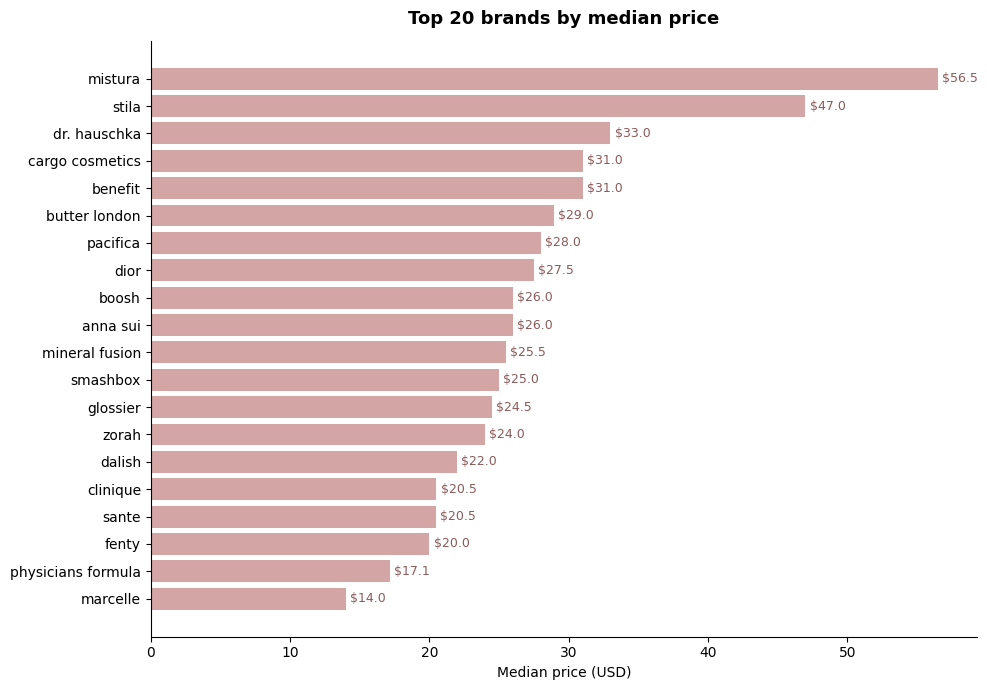


Figure 6 — Price distribution by brand - Top 20.


In [ ]:
price_by_brand = (
    df.drop_duplicates(subset="id")
    .groupby("brand")["price"]
    .median()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(price_by_brand.index, price_by_brand.values,
               color="#D4A5A5", edgecolor="none")
ax.set_title("Top 20 brands by median price", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Median price (USD)")
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()

for bar, val in zip(bars, price_by_brand.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"${val:.1f}", va="center", fontsize=9, color="#8B5A5A")

plt.tight_layout()
plt.savefig("fig6_price_distribution_by_brand.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 6 — Price distribution by brand - Top 20.")

# 7. Shade count per product type

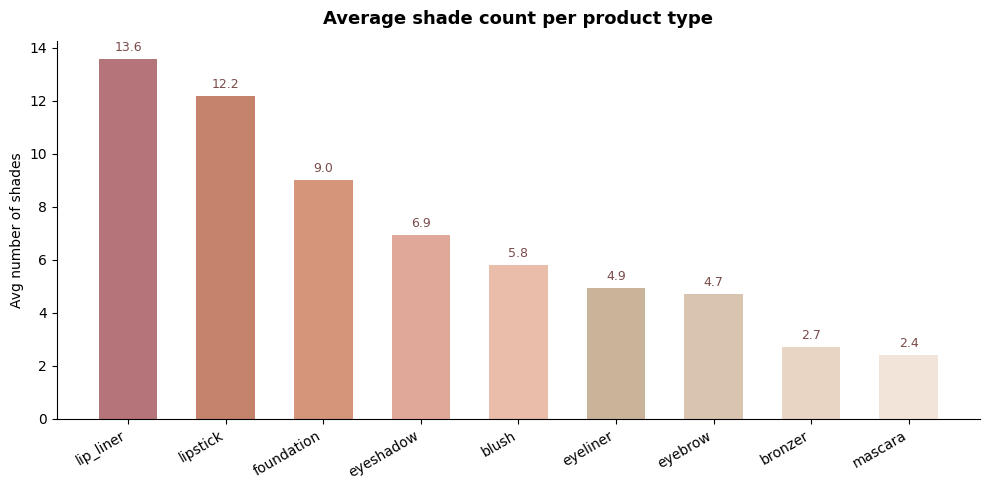


Figure 7— Shade count per product type


In [ ]:
shade_counts = (
    df.groupby(["product_type", "id"])
    .size()
    .reset_index(name="shade_count")
    .groupby("product_type")["shade_count"]
    .mean()
    .sort_values(ascending=False)
)

# Gradient from deep rose to light nude across bars
bar_colors = ["#B5737A", "#C4836A", "#D4957A", "#E0A898", "#EABCAA",
              "#C9B49A", "#D9C4B0", "#E8D5C4", "#F2E4D8"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(shade_counts.index, shade_counts.values,
              color=bar_colors[:len(shade_counts)], edgecolor="none", width=0.6)
ax.set_title("Average shade count per product type", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Avg number of shades")
ax.set_xlabel("")
ax.set_xticklabels(shade_counts.index, rotation=30, ha="right")
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, shade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", fontsize=9, color="#7A4A4A")

plt.tight_layout()
plt.savefig("fig7_shade_count_product_type.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 7— Shade count per product type")

# 8. Shade color distribution (R vs B scatter)

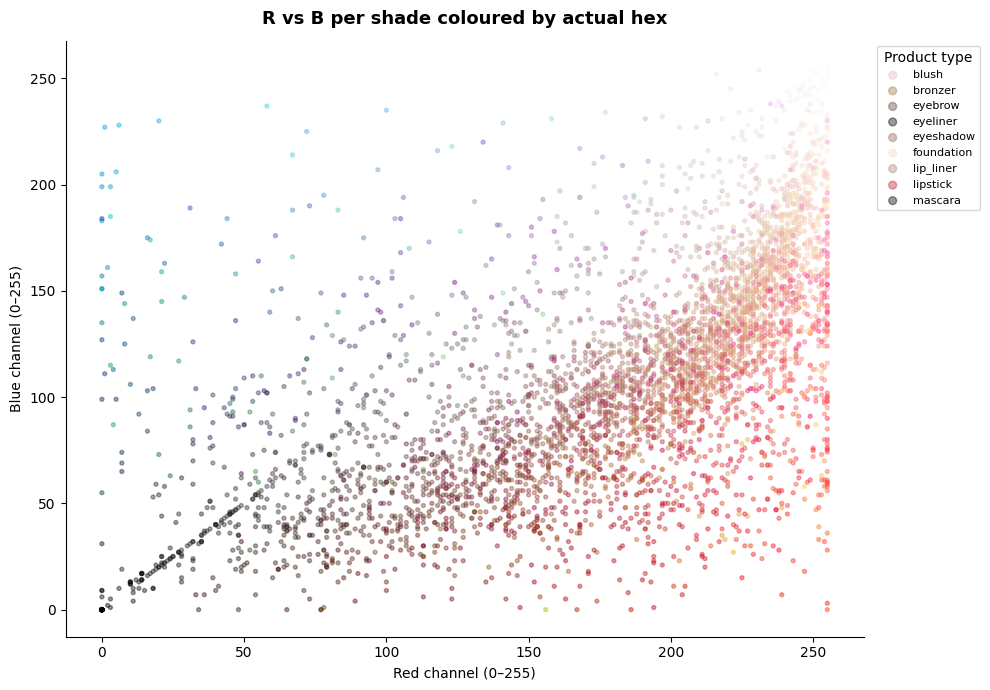


Figure 8 — Shade color distribution ( R vs B scatter).


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

for ptype, group in df.groupby("product_type"):
    ax.scatter(group["r"], group["b"],
               c=["#" + h for h in group["hex"]],
               alpha=0.4, s=8, label=ptype)

ax.set_title("R vs B per shade coloured by actual hex", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Red channel (0–255)")
ax.set_ylabel("Blue channel (0–255)")
ax.legend(title="Product type", bbox_to_anchor=(1.01, 1), loc="upper left",
          markerscale=2, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig8_shade_color_distribution_(r vs B scatter).png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 8 — Shade color distribution ( R vs B scatter).")

# 9. Luminance distribution by product type


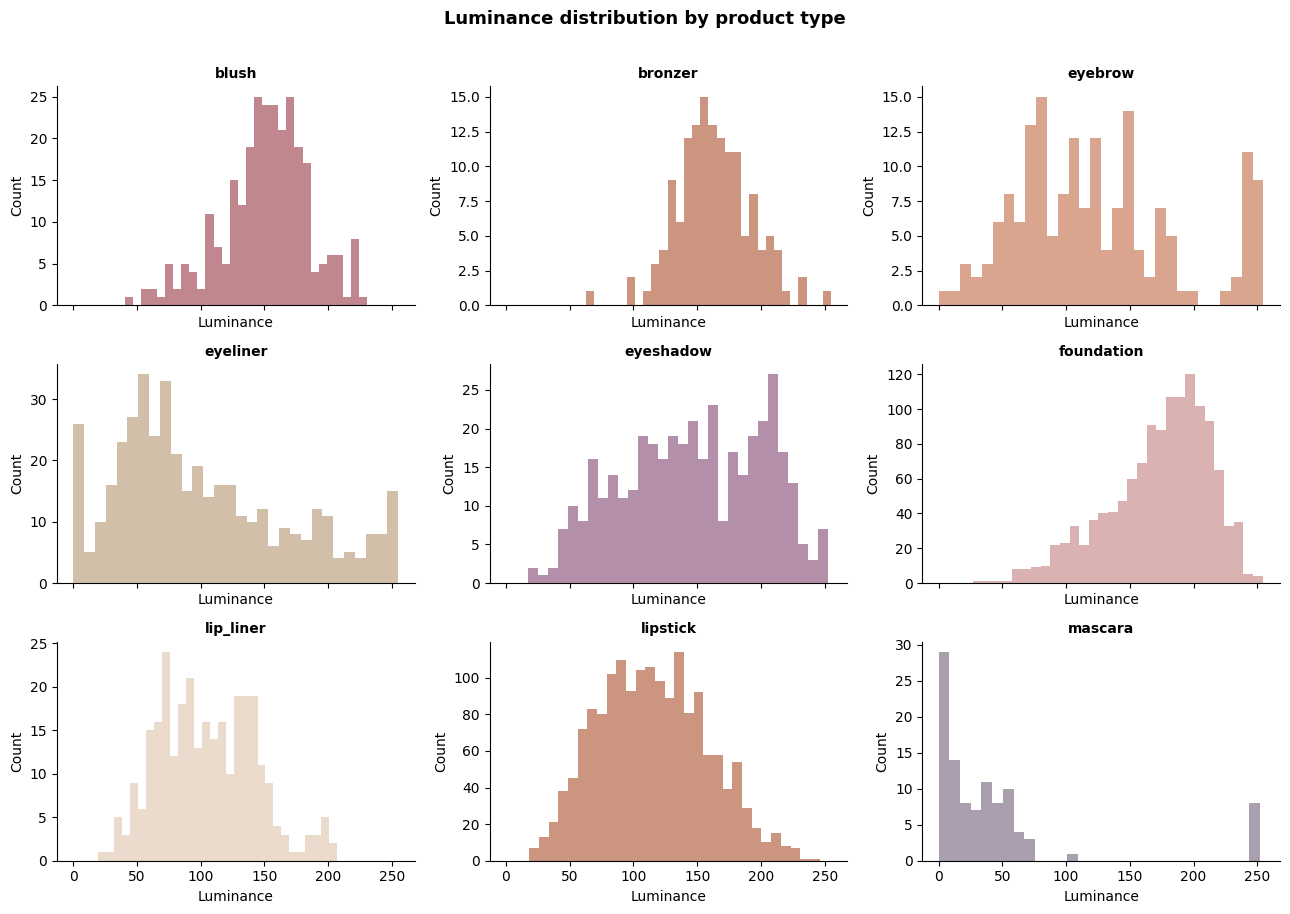


Figure 9 —  Luminance distribution by product type .


In [ ]:
product_types = df["product_type"].unique()
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
axes = axes.flatten()

lum_colors = ["#B5737A", "#C4836A", "#D4957A", "#C9B49A",
               "#A67B9B", "#D4A5A5", "#E8D5C4", "#C4836A", "#9B8EA0"]

for i, ptype in enumerate(sorted(product_types)):
    data = df[df["product_type"] == ptype]["luminance"]
    axes[i].hist(data, bins=30, color=lum_colors[i], edgecolor="none", alpha=0.85)
    axes[i].set_title(ptype, fontsize=10, fontweight="bold")
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].set_xlabel("Luminance")
    axes[i].set_ylabel("Count")

# hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Luminance distribution by product type", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig9_luminance_distribution_product_type.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 9 —  Luminance distribution by product type .")

# 10. Luminance distribution by category (boxplot)

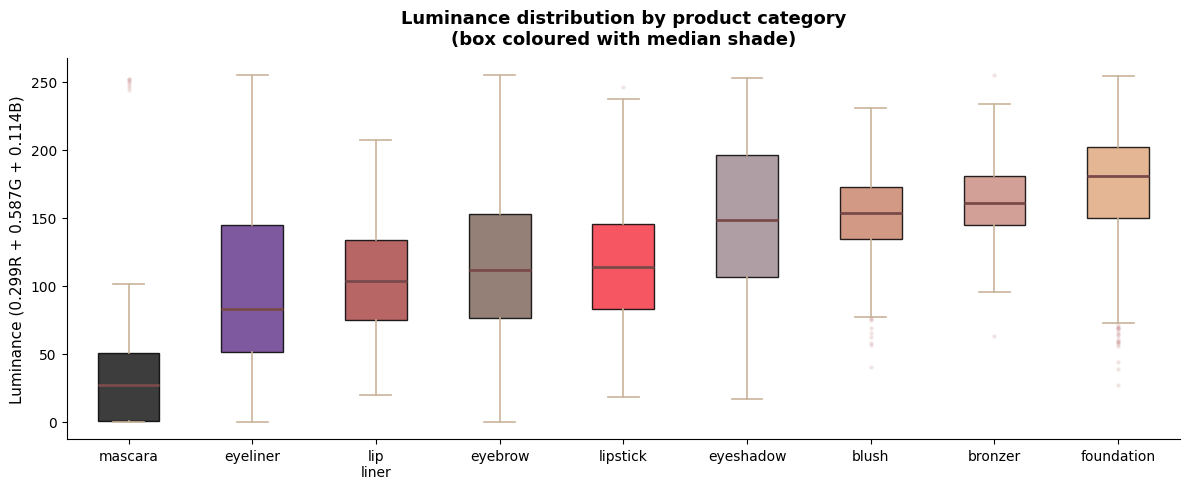


Figure 10 —  Luminance distribution by category.


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
cats_ordered = df.groupby('product_type')['luminance'].median().sort_values().index.tolist()
data_to_plot = [df[df['product_type'] == c]['luminance'].values for c in cats_ordered]

hex_medians = []
for c in cats_ordered:
    sub_df = df[df['product_type'] == c]
    if not sub_df.empty:
        median_luminance = sub_df['luminance'].median()
        idx_closest = (sub_df['luminance'] - median_luminance).abs().idxmin()
        hex_medians.append(sub_df.loc[idx_closest, 'hex'])
    else:
        hex_medians.append('FFFFFF')

bp = ax.boxplot(data_to_plot, vert=True, patch_artist=True,
                medianprops=dict(color='#7A4A4A', linewidth=2),
                whiskerprops=dict(color='#C9B49A', linewidth=1.2),
                capprops=dict(color='#C9B49A', linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3,
                                markerfacecolor='#D4A5A5', markeredgecolor='none'))

for patch, hx in zip(bp['boxes'], hex_medians):
    patch.set_facecolor('#' + hx)
    patch.set_alpha(0.85)

ax.set_xticks(range(1, len(cats_ordered)+1))
ax.set_xticklabels([c.replace('_', '\n') for c in cats_ordered], fontsize=10)
ax.set_ylabel("Luminance (0.299R + 0.587G + 0.114B)", fontsize=11)
ax.set_title("Luminance distribution by product category\n(box coloured with median shade)",
             fontsize=13, fontweight='bold', pad=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("fig10_luminance_by_category.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 10 —  Luminance distribution by category.")

#11. The importance of Appropriate Color Representation

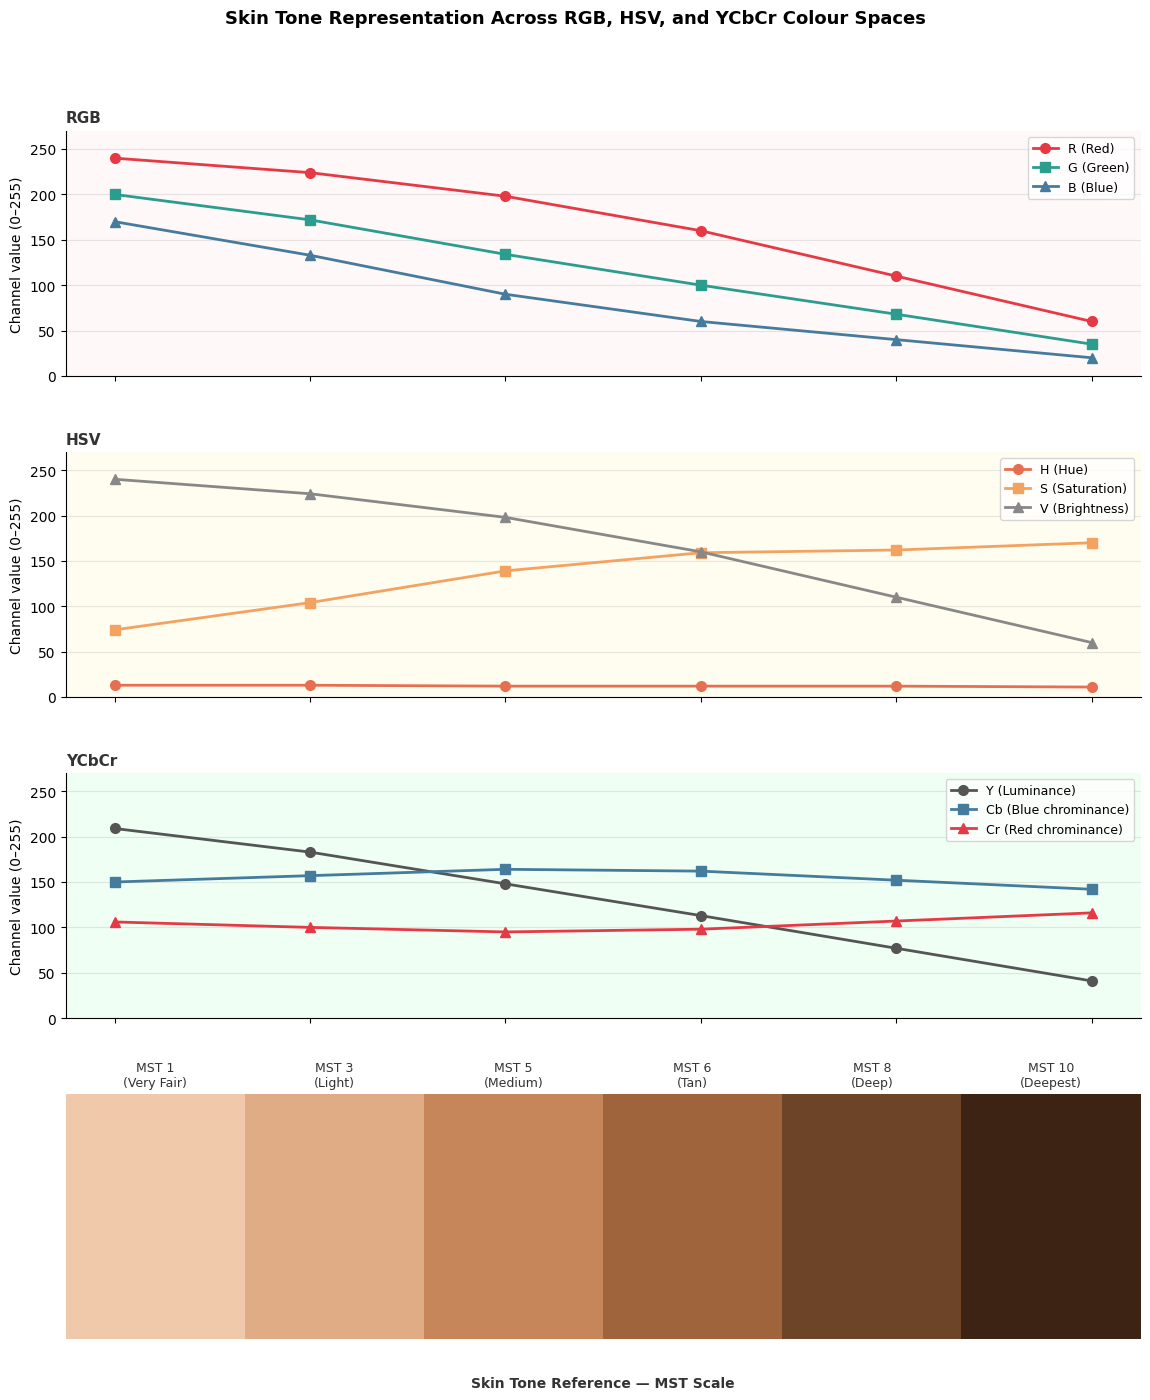

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

skin_tones_rgb = np.array([
    [240, 200, 170],
    [224, 172, 133],
    [198, 134, 90],
    [160, 100, 60],
    [110, 68,  40],
    [60,  35,  20],
], dtype=np.uint8)

labels = ['MST 1\n(Very Fair)', 'MST 3\n(Light)', 'MST 5\n(Medium)',
          'MST 6\n(Tan)', 'MST 8\n(Deep)', 'MST 10\n(Deepest)']

def to_hsv(rgb):
    bgr = rgb[::-1].reshape(1,1,3)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)[0,0]

def to_ycbcr(rgb):
    bgr = rgb[::-1].reshape(1,1,3)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)[0,0]

hsv_vals   = np.array([to_hsv(c)   for c in skin_tones_rgb])
ycbcr_vals = np.array([to_ycbcr(c) for c in skin_tones_rgb])

x = np.arange(len(skin_tones_rgb))

fig, axes = plt.subplots(4, 1, figsize=(12, 14))

ax_rgb    = axes[0]
ax_hsv    = axes[1]
ax_ycbcr  = axes[2]
ax_swatch = axes[3]

# ── Row 0: RGB ────────────────────────────────────────────────────────────
ax = ax_rgb
ax.plot(x, skin_tones_rgb[:,0], 'o-', color='#E63946', linewidth=2, markersize=7, label='R (Red)')
ax.plot(x, skin_tones_rgb[:,1], 's-', color='#2A9D8F', linewidth=2, markersize=7, label='G (Green)')
ax.plot(x, skin_tones_rgb[:,2], '^-', color='#457B9D', linewidth=2, markersize=7, label='B (Blue)')
ax.set_ylabel('Channel value (0–255)')
ax.set_title('RGB', fontsize=11, fontweight='bold', color='#333333', loc='left')
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_ylim(0, 270)
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#FFF8F8')

# ── Row 1: HSV ────────────────────────────────────────────────────────────
ax = ax_hsv
ax.plot(x, hsv_vals[:,0], 'o-', color='#E76F51', linewidth=2, markersize=7, label='H (Hue)')
ax.plot(x, hsv_vals[:,1], 's-', color='#F4A261', linewidth=2, markersize=7, label='S (Saturation)')
ax.plot(x, hsv_vals[:,2], '^-', color='#888888', linewidth=2, markersize=7, label='V (Brightness)')
ax.set_ylabel('Channel value (0–255)')
ax.set_title('HSV', fontsize=11, fontweight='bold', color='#333333', loc='left')
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_ylim(0, 270)
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#FFFDF0')

# ── Row 2: YCbCr ──────────────────────────────────────────────────────────
ax = ax_ycbcr
ax.plot(x, ycbcr_vals[:,0], 'o-', color='#555555', linewidth=2, markersize=7, label='Y (Luminance)')
ax.plot(x, ycbcr_vals[:,1], 's-', color='#457B9D', linewidth=2, markersize=7, label='Cb (Blue chrominance)')
ax.plot(x, ycbcr_vals[:,2], '^-', color='#E63946', linewidth=2, markersize=7, label='Cr (Red chrominance)')
ax.set_ylabel('Channel value (0–255)')
ax.set_title('YCbCr', fontsize=11, fontweight='bold', color='#333333', loc='left')
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_ylim(0, 270)
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#F0FFF4')

# ── Row 3: Skin tone swatches (bottom) ────────────────────────────────────
ax = ax_swatch
for i, (color, label) in enumerate(zip(skin_tones_rgb, labels)):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color/255, linewidth=0))
ax.set_xlim(0, 6)
ax.set_ylim(0, 1)
ax.set_xticks([i + 0.5 for i in range(6)])
ax.set_xticklabels(labels, fontsize=9, color='#333333')
ax.set_yticks([])
ax.xaxis.set_tick_params(length=0)
ax.xaxis.set_ticks_position('top')   # ← only change
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.text(3, -0.15, 'Skin Tone Reference — MST Scale',
        ha='center', va='top', fontsize=10,
        fontweight='bold', color='#333333',
        transform=ax.transData)

plt.suptitle('Skin Tone Representation Across RGB, HSV, and YCbCr Colour Spaces',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.5)
plt.savefig('/content/fig_color_space_comparison.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

from google.colab import files
files.download('/content/fig_color_space_comparison.png')
print('✅ Downloaded!')

#12. Pixel based vs Segmentation based

In [ ]:
from google.colab import files
uploaded = files.upload()
photo_path = list(uploaded.keys())[0]
print(f'Uploaded: {photo_path}')

Saving IMG_0598.jpg to IMG_0598.jpg
Uploaded: IMG_0598.jpg


Image loaded: (200, 200, 3)


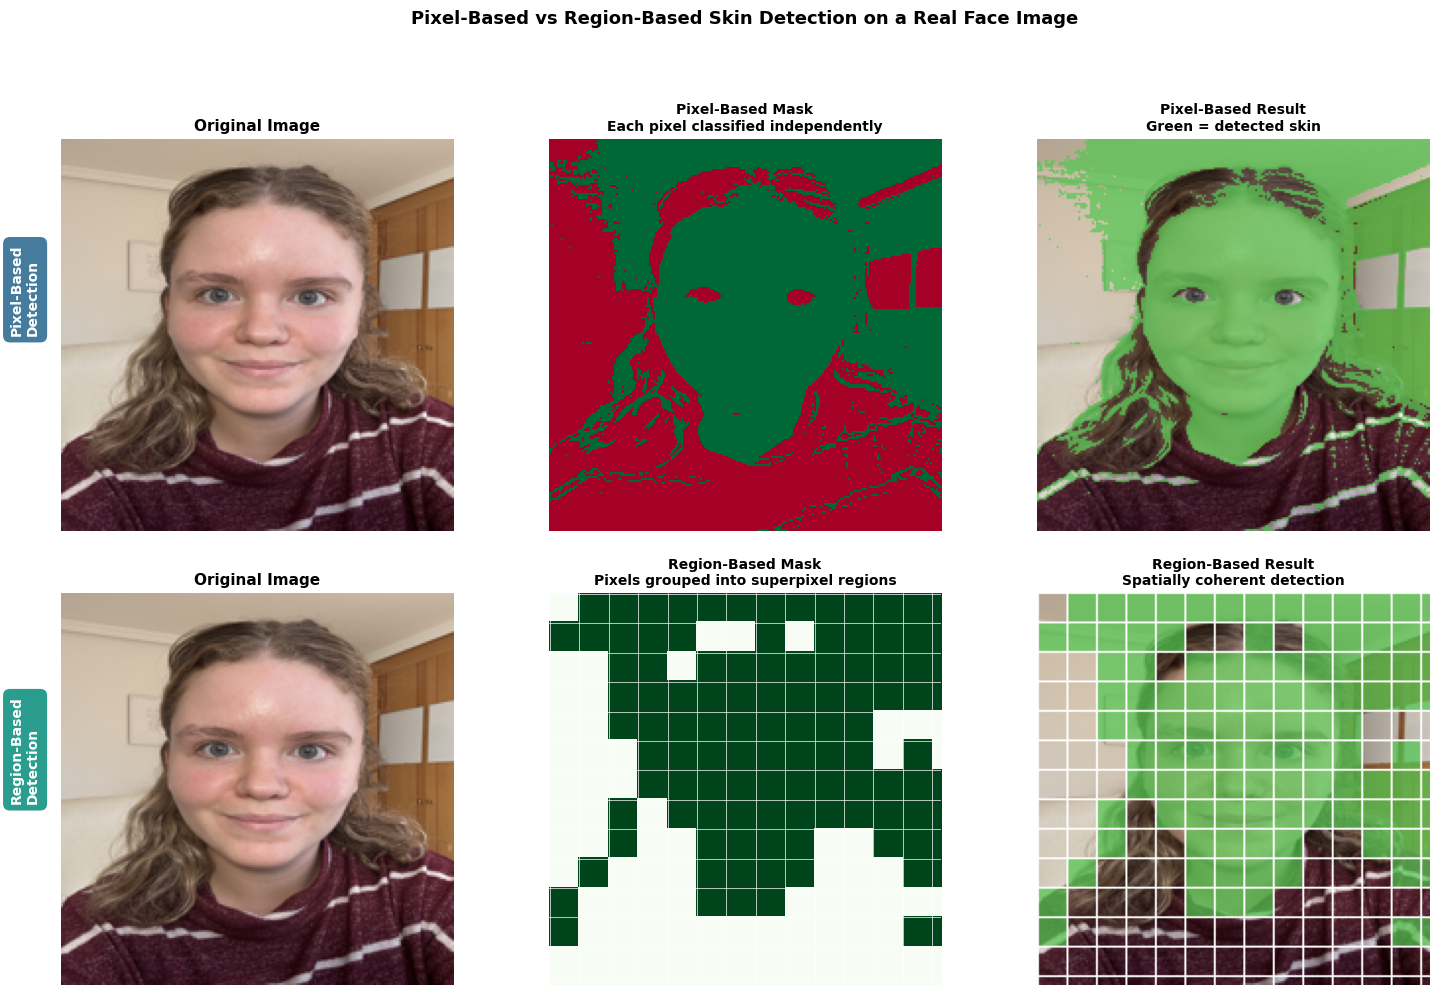

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import cv2

# ── Load your photo ────────────────────────────────────────────────────────
img_pil = Image.open(photo_path).convert('RGB')
img_pil = ImageOps.exif_transpose(img_pil)

# Resize to square
img_pil = img_pil.resize((200, 200))
img = np.array(img_pil)
print(f'Image loaded: {img.shape}')

# ── Pixel-based skin detection ─────────────────────────────────────────────
def is_skin_pixel(r, g, b):
    return (r > 95 and g > 40 and b > 20 and
            r > g and r > b and
            abs(int(r) - int(g)) > 15 and
            r > 100)

H, W = img.shape[:2]
pixel_mask = np.zeros((H, W), dtype=np.uint8)
for y in range(H):
    for x in range(W):
        r, g, b = int(img[y,x,0]), int(img[y,x,1]), int(img[y,x,2])
        pixel_mask[y,x] = 1 if is_skin_pixel(r, g, b) else 0

# ── Region-based detection ─────────────────────────────────────────────────
block_size = 15
region_mask = np.zeros((H, W), dtype=np.uint8)

for by in range(0, H, block_size):
    for bx in range(0, W, block_size):
        block = img[by:by+block_size, bx:bx+block_size]
        mean_r = float(block[:,:,0].mean())
        mean_g = float(block[:,:,1].mean())
        mean_b = float(block[:,:,2].mean())
        if is_skin_pixel(mean_r, mean_g, mean_b):
            region_mask[by:by+block_size, bx:bx+block_size] = 1

# ── Overlays ───────────────────────────────────────────────────────────────
def make_overlay(image, mask, color):
    overlay = image.copy().astype(float)
    overlay[mask == 1] = overlay[mask == 1] * 0.3 + np.array(color) * 0.7
    return overlay.astype(np.uint8)

overlay_pixel  = make_overlay(img, pixel_mask,  [80, 200, 80])
overlay_region = make_overlay(img, region_mask, [80, 200, 80])

# Draw superpixel grid on region result
overlay_region_grid = overlay_region.copy()
for by in range(0, H, block_size):
    overlay_region_grid[by, :] = [255, 255, 255]
for bx in range(0, W, block_size):
    overlay_region_grid[:, bx] = [255, 255, 255]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor('white')

# Row 0 — Pixel-based
axes[0][0].imshow(img)
axes[0][0].set_title('Original Image', fontsize=11, fontweight='bold')
axes[0][0].axis('off')

axes[0][1].imshow(pixel_mask, cmap='RdYlGn', vmin=0, vmax=1, interpolation='nearest')
axes[0][1].set_title('Pixel-Based Mask\nEach pixel classified independently', fontsize=10, fontweight='bold')
axes[0][1].axis('off')

axes[0][2].imshow(overlay_pixel)
axes[0][2].set_title('Pixel-Based Result\nGreen = detected skin', fontsize=10, fontweight='bold')
axes[0][2].axis('off')

# Row 1 — Region-based
axes[1][0].imshow(img)
axes[1][0].set_title('Original Image', fontsize=11, fontweight='bold')
axes[1][0].axis('off')

axes[1][1].imshow(region_mask, cmap='Greens', vmin=0, vmax=1, interpolation='nearest')
for by in range(0, H, block_size):
    axes[1][1].axhline(by, color='white', linewidth=0.5)
for bx in range(0, W, block_size):
    axes[1][1].axvline(bx, color='white', linewidth=0.5)
axes[1][1].set_title('Region-Based Mask\nPixels grouped into superpixel regions', fontsize=10, fontweight='bold')
axes[1][1].axis('off')

axes[1][2].imshow(overlay_region_grid)
axes[1][2].set_title('Region-Based Result\nSpatially coherent detection', fontsize=10, fontweight='bold')
axes[1][2].axis('off')

# Row labels
for row, (label, color) in enumerate([('Pixel-Based\nDetection', '#457B9D'),
                                        ('Region-Based\nDetection', '#2A9D8F')]):
    fig.text(0.01, 0.73 - row * 0.46, label,
             ha='left', va='center', fontsize=10, fontweight='bold',
             rotation=90, color='white',
             bbox=dict(boxstyle='round,pad=0.5',
                       facecolor=color, edgecolor='none'))


plt.suptitle('Pixel-Based vs Region-Based Skin Detection on a Real Face Image',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout(pad=2.5)
plt.savefig('/content/fig_skin_detection_real_face.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

from google.colab import files
files.download('/content/fig_skin_detection_real_face.png')
print('✅ Downloaded!')